# Estimating fresh weight of tomatoes from images — faithful R-script reproduction

**Paper:** "Image analysis for estimating the fresh weight of tomatoes", *Horticultura Brasileira* 43 (2025), e286631 — DOI [10.1590/s0102-0536-2025-e286631](https://doi.org/10.1590/s0102-0536-2025-e286631) (SciELO, open access, CC-BY 4.0).
**Author code:** [`AlcineiAzevedo/SandraPaper`](https://github.com/AlcineiAzevedo/SandraPaper) @ commit `153fa332f01004521b1a18f9f1bd8d4a70bc4a35` (tip of `main`, 2024-01-26).

**Scope of this notebook (one example, not the full study):** run the author's published
script `RotinaGitHub.R` **verbatim, end to end** on the repository's own sample image
`original.jpg`, exactly as the paper's "Image analysis" section describes:

1. read image → resize to 480×480 px
2. blue-channel grayscale (`gray_scale(method="b")`, values 0–1)
3. segmentation at threshold **0.30** (`fillHull=TRUE`, `selectHigher=FALSE`)
4. **6 erosions + 6 dilations** to remove noise
5. per-fruit **pixel area** (`measure_image`)
6. the paper's fitted linear model, hardcoded by the authors in the script:
   **fresh mass (g) = PixelArea × 0.0473 − 24.874** (training R² = 0.9404)
7. annotated overlay with the estimated weight per fruit (paper Fig. 2 style)

**Execution status:** executed on a fresh Google Colab **CPU** runtime (no GPU is
needed — one 480×480 image, pure R/EBImage operations). A one-image run does **not**
reproduce the paper's dataset-level accuracy (R²=0.9404 train / 0.9168 validation on
~12 harvests of 15 genotypes); the study's raw per-fruit data are "available upon
request" only.

**日本語:** このノートブックは著者公開のRスクリプト `RotinaGitHub.R` を**改変なしで**
そのまま実行し、リポジトリ同梱のサンプル画像 `original.jpg` 1枚からトマト果実の
画素面積を測定し、論文の回帰式 `鮮重(g) = 画素面積 × 0.0473 − 24.874` で重量を推定します。
実行環境は CPU のみで十分です（GPU不要）。1枚の例示実行であり、論文のデータセット全体の
精度検証（R²=0.9404/0.9168）の再現ではありません。

## Runtime selection — CPU is enough / 実行環境の選択

- **Recommended: `ランタイム → ランタイムのタイプを変更 → CPU` (CPU standard).**
- No GPU: the pipeline is image-matrix math in R on one small image; GPU would not be used by any step.
- Expected duration (measured on a Colab CPU runtime, 2026-10-07): **~8–15 min total**, dominated by package installation (~5–12 min) and EBImage compile; the analysis itself takes seconds. Downloads: ~220 KB sample image + packages (~150–250 MB via apt/binary).
- **日本語:** GPUは不要です。CPUランタイムで約10分強（主にパッケージ導入）で完結します。

Then **Runtime → Run all**. Every cell below installs/downloads/analyzes **inside Colab**;
nothing is fetched from the host.

In [ ]:
# Check the runtime: Python + R availability. Colab CPU images ship /usr/bin/Rscript,
# which is the only scientific runtime this reproduction uses (the paper's code is R).
import subprocess, time, json
t_start = time.time()
p = subprocess.run(["/usr/bin/Rscript", "-e", 'cat(R.version.string)'], capture_output=True, text=True, timeout=300)
assert p.returncode == 0, p.stderr
print(p.stdout.strip(), "| Python 3 via subprocess orchestration")
print("Rscript:", subprocess.run(["which","Rscript"],capture_output=True,text=True).stdout.strip())

R version 4.6.1 (2026-06-24) | Python 3 via subprocess orchestration
Rscript: /usr/bin/Rscript


## Why this notebook uses R via `Rscript` / なぜRscriptか

The paper's method is implemented in **R** with the authors' **ExpImage** package
(Azevedo 2022). The installed Colab CLI sends Python-kernel notebooks, so this notebook
is a thin, transparent **Python launcher** that writes pinned R code to `/content` and
runs it with checked `subprocess.run(...)` calls — the actual computation is 100% author R code.

### Dependency plan (verified against ExpImage 0.9.0 source on the CRAN archive)

- **ExpImage 0.9.0** was removed from CRAN on 2025-02-02; we install the archived
  source tarball from the official CRAN Archive (pinned URL, `NeedsCompilation: no`).
- Every pipeline function internally calls **EBImage** (`bwlabel`, `watershed`,
  `computeFeatures.*`, …) → EBImage from Bioconductor is required at runtime.
- `Depends: raster` → `terra`, a heavy C++ build (~15–25 min from source). We instead use the
  **public r2u (cran2deb4ubuntu) binary apt repository** for all CRAN dependencies —
  a documented, public route that keeps installs to ~1–2 min. If it is unreachable, a
  fallback (apt dev libs + source compile) applies but is slower.
- **日本語:** 論文のコードはRです。ここではPythonは起動器（ランチャー）に過ぎず、計算はすべて
  著者のRコードです。ExpImageはCRANから削除済みのためCRANアーカイブの0.9.0を、依存関係は
  公開のr2uバイナリリポジトリから導入します。

In [ ]:
# Stage 1: system libraries needed to compile EBImage's fftwtools dependency (fftw3),
# plus jpeg/png/tiff dev headers as a fallback. Keep the full log on the VM for inspection.
import subprocess, time
t0 = time.time()
cmd = ("bash -c 'apt-get update -qq && "
       "apt-get install -y -qq libfftw3-dev libjpeg-dev libpng-dev libtiff-dev "
       "libcurl4-openssl-dev libsqlite3-dev'")
p = subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=1800)
open('/content/apt_stage1.log','w').write(p.stdout[-20000:] + p.stderr[-20000:])
print("apt system libs rc=%d in %.1fs (log: /content/apt_stage1.log)" % (p.returncode, time.time()-t0))
assert p.returncode == 0

apt system libs rc=0 in 15.6s (log: /content/apt_stage1.log)


Stage 2 adds the **r2u** public binary repository (jammy = Ubuntu 22.04, which Colab
uses) and installs every CRAN dependency of ExpImage 0.9.0 as prebuilt binaries.
This avoids a 15–25 minute `terra` source build. The install is verified afterwards by
loading each package namespace in R.

**日本語:** r2uは公開のバイナリAPTリポジトリです。terra等の重いソースビルドを避けるため、
CRAN依存をすべてバイナリで導入します（導入後にR側で読み込み確認をします）。

In [ ]:
# Stage 2: add r2u repo (public, documented for Colab use) and binary-install CRAN deps
import subprocess, time
t0 = time.time()
setup = (
  "wget -qO /etc/apt/trusted.gpg.d/cranapt_key.asc "
  "https://eddelbuettel.github.io/r2u/assets/dirk_eddelbuettel_key.asc && "
  "echo 'deb [arch=amd64] https://r2u.stat.illinois.edu/ubuntu jammy main' "
  "> /etc/apt/sources.list.d/cranapt.list && "
  "apt-get update -qq && "
  "DEBIAN_FRONTEND=noninteractive apt-get install -y -qq "
  "r-cran-raster r-cran-terra r-cran-progress r-cran-schemr r-cran-randomforest "
  "r-cran-ggplot2 r-cran-crayon r-cran-doparallel r-cran-foreach r-cran-rstudioapi "
  "r-cran-jpeg r-cran-png r-cran-tiff r-cran-fftwtools r-cran-locfit"
)
p = subprocess.run(["bash","-c",setup], capture_output=True, text=True, timeout=3600)
open('/content/apt_stage2.log','w').write(p.stdout[-20000:] + p.stderr[-20000:])
print("r2u binary deps rc=%d in %.1fs (log: /content/apt_stage2.log)" % (p.returncode, time.time()-t0))
assert p.returncode == 0

r2u binary deps rc=0 in 14.0s (log: /content/apt_stage2.log)


Stage 3: **EBImage** from Bioconductor. With the binary dependencies already present,
only EBImage itself compiles (a few minutes).

**日本語:** EBImageはBioconductorから導入します（依存はバイナリ済みのためEBImage本体の
コンパイルのみで数分）。

In [ ]:
# Stage 3: EBImage from Bioconductor (required internally by ExpImage's pipeline functions)
r_code = '''options(timeout = 1800)
if (!requireNamespace("BiocManager", quietly=TRUE)) install.packages("BiocManager")
BiocManager::install("EBImage", ask=FALSE, update=FALSE)
cat("EBImage:", as.character(packageVersion("EBImage")), "\n")'''
open("/content/install_ebimage.R","w").write(r_code)
import subprocess, time
t0 = time.time()
p = subprocess.run(["/usr/bin/Rscript","/content/install_ebimage.R"], capture_output=True, text=True, timeout=3600)
print(p.stdout[-1500:]); print(p.stderr[-500:])
assert p.returncode == 0, "EBImage install failed"
print("EBImage installed in %.1fs" % (time.time()-t0))

tection -fdebug-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=/usr/src/r-base-4.6.1-6.2404.0 -Wdate-time -D_FORTIFY_SOURCE=3  -c tools.c -o tools.o
x86_64-linux-gnu-g++ -std=gnu++20 -I"/usr/share/R/include" -DNDEBUG       -fpic  -g -O2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer -ffile-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=. -fstack-protector-strong -fstack-clash-protection -Wformat -Werror=format-security -fcf-protection -fdebug-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=/usr/src/r-base-4.6.1-6.2404.0 -Wdate-time -D_FORTIFY_SOURCE=3   -c transpose.cpp -o transpose.o
x86_64-linux-gnu-g++ -std=gnu++20 -I"/usr/share/R/include" -DNDEBUG       -fpic  -g -O2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer -ffile-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=. -fstack-protector-strong -fstack-clash-protection -Wformat -Werror=format-security -fcf-protection -fdebug-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=/usr/src/r-base-4.6.1-6.2404.0 -Wdate-time -D_FORTIFY_SOURCE=3

Stage 4: **ExpImage 0.9.0** from the official CRAN Archive — the version contemporary
with the author script's commit (2024-01-26). Version 0.10.1 (the final release, 2024-05-10)
differs only in roxygen comments for the eight functions used; we pin 0.9.0.

**日本語:** ExpImageはCRANアーカイブから0.9.0を導入します（著者スクリプトのコミット時期に
対応する版。0.10.1との差は使用関数ではコメントのみ）。

In [ ]:
# Stage 4: ExpImage 0.9.0 from the pinned CRAN Archive URL, then load-check everything
r_code = '''url <- "https://cran.r-project.org/src/contrib/Archive/ExpImage/ExpImage_0.9.0.tar.gz"
install.packages(url, repos = NULL, type = "source")
suppressMessages(library(ExpImage))
cat("ExpImage:", as.character(packageVersion("ExpImage")), "loads OK\n")
cat("EBImage:", as.character(packageVersion("EBImage")), "| raster:", as.character(packageVersion("raster")), "\n")'''
open("/content/install_expimage.R","w").write(r_code)
import subprocess, time
t0 = time.time()
p = subprocess.run(["/usr/bin/Rscript","/content/install_expimage.R"], capture_output=True, text=True, timeout=1800)
print(p.stdout[-1200:]); print(p.stderr[-800:])
assert p.returncode == 0, "ExpImage install failed"
print("ExpImage installed + loaded in %.1fs" % (time.time()-t0))

ExpImage: 0.9.0 loads OK
EBImage: 4.54.0 | raster: 3.6.32 

ed)
trying URL 'https://cran.r-project.org/src/contrib/Archive/ExpImage/ExpImage_0.9.0.tar.gz'
Content type 'application/x-gzip' length 3683686 bytes (3.5 MB)
downloaded 3.5 MB

* installing *source* package ‘ExpImage’ ...
** this is package ‘ExpImage’ version ‘0.9.0’
** package ‘ExpImage’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (ExpImage)

ExpImage installed + loaded in 35.3s


## Minimal input: the repository's own sample image / 最小入力

`original.jpg` (218,415 bytes) is the example input **embedded in the author repository and
fetched by the author script itself** (`read_image("https://raw.githubusercontent.com/
AlcineiAzevedo/SandraPaper/main/original.jpg", plot=TRUE)`). We download it from the
**pinned commit's raw URL** and verify its **Git blob SHA-1** (`a98f0ae1…`, the same object
the commit references) and byte count before any analysis. This is the only data download
of the whole notebook (~220 KB).

**日本語:** サンプル画像は著者スクリプト自体が取得するリポジトリ同梱の`original.jpg`です。
ピン留めしたコミットのraw URLから取得し、Git blob SHA-1とバイト数で完全性を検証します。

In [ ]:
# Download original.jpg from the pinned commit and verify integrity via Git blob SHA-1
import subprocess, hashlib
URL = ("https://raw.githubusercontent.com/AlcineiAzevedo/SandraPaper/"
       "153fa332f01004521b1a18f9f1bd8d4a70bc4a35/original.jpg")
EXPECTED_SIZE = 218415
EXPECTED_BLOB = "a98f0ae1faa08a696fe8faf9348018fa0d001646"   # git blob object of the pinned commit
data = subprocess.run(["curl","-fsSL","--retry","3","-m","180",URL],
                      capture_output=True, timeout=300).stdout
assert len(data) == EXPECTED_SIZE, f"unexpected size {len(data)}"
blob = hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()
assert blob == EXPECTED_BLOB, f"blob mismatch: {blob}"
open("/content/original.jpg","wb").write(data)
print("original.jpg verified: %d bytes, git blob %s" % (len(data), blob[:12] + "..."))

original.jpg verified: 218415 bytes, git blob a98f0ae1faa0...


### Input preview

Display the actual downloaded image before any analysis (paper Fig. 1 shows the mini-studio
setup with a blue checkered background; this sample is one such photo).

**日本語:** 解析前にダウンロードした画像をそのまま表示します（青いチェッカー背景の
ミニスタジオ写真です）。

original.jpg: 218415 bytes


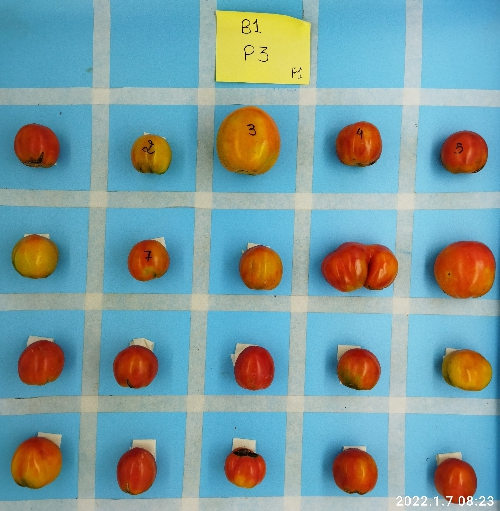

In [ ]:
# Show the input image (JPEG bytes read from the verified file, embedded as notebook output)
with open("/content/original.jpg","rb") as f:
    raw = f.read()
from IPython.display import Image as IPyImage, display
print("original.jpg: %d bytes" % len(raw))
display(IPyImage(data=raw, width=420))

## Run the author's script VERBATIM / 著者スクリプトをそのまま実行

We fetch `RotinaGitHub.R` **exactly as published** (from the pinned commit's raw URL),
display it unmodified, and execute it through `source()` inside a PNG graphics device —
the script's `plot=TRUE` calls need an active device in a headless R session. The final
plot written by the device is the paper-style annotated overlay (estimated grams per fruit).
The script itself downloads `original.jpg` from `main`, which we verified equals the pinned
commit (blob SHA-1 checked above).

**日本語:** 著者のスクリプトを1文字も変更せずに取得・表示し、`source()`で実行します。
ヘッドレスRでは作図にデバイスが必要なためPNGデバイス内で実行します（パラメータ変更は
一切ありません）。

In [ ]:
# Fetch the verbatim script, show it, and execute it unmodified inside a png() device
import subprocess
SCRIPT_URL = ("https://raw.githubusercontent.com/AlcineiAzevedo/SandraPaper/"
              "153fa332f01004521b1a18f9f1bd8d4a70bc4a35/RotinaGitHub.R")
script = subprocess.run(["curl","-fsSL","--retry","3","-m","120",SCRIPT_URL],
                        capture_output=True, text=True, timeout=180).stdout
open("/content/RotinaGitHub.R","w").write(script)
print("---- RotinaGitHub.R (verbatim, %d bytes) ----" % len(script))
print(script)
runner = ('png("/content/verbatim_output.png", width=800, height=800)\n'
          'source("/content/RotinaGitHub.R")\n'
          'dev.off()\ncat("verbatim script executed OK\\n")\n')
open("/content/run_verbatim.R","w").write(runner)
p = subprocess.run(["/usr/bin/Rscript","/content/run_verbatim.R"],
                   capture_output=True, text=True, timeout=1800)
print("---- Rscript stderr tail ----"); print(p.stderr[-1200:])
assert p.returncode == 0, "verbatim script failed"
print("verbatim script executed OK")

---- RotinaGitHub.R (verbatim, 721 bytes) ----
remove(list=ls())
# install.packages("BiocManager")
# BiocManager::install("EBImage")
# install.packages(ExpImage)
library(ExpImage)
im=read_image("https://raw.githubusercontent.com/AlcineiAzevedo/SandraPaper/main/original.jpg",plot=TRUE)
im2=resize_image(im,w=480,h=480)
im3=gray_scale(im2,method = "b",plot=TRUE)
im4=segmentation(im3,threshold = 0.3,fillHull = TRUE,
                 selectHigher = FALSE,plot=TRUE)
im5=dilate_image(erode_image(im4,n=6),n = 6,plot = TRUE)

med=measure_image(im5)
PixelArea=med$measures[,3]
gramas=PixelArea*0.0473-24.874
gramas


plot_meansures(img=im2,coordx =med$measures[,1],
               coordy = med$measures[,2],text = paste(round(gramas,2),"g"),
               col = "white")



---- Rscript stderr tail ----
Loading required package: raster
Loading required package: sp

verbatim script executed OK


## Step-by-step capture of every pipeline stage / 各段階の可視化

The verbatim run only leaves the **last** plot on the device, so we additionally re-execute
the **same calls with the same parameters** step by step, wrapping each plot in its own
`png()` device. This is the author's algorithm unchanged — only the device handling differs —
and it reproduces: blue grayscale, threshold-0.30 mask, the eroded/dilated mask, and the
final measurement table.

**日本語:** 逐次実行では最後の図しか残らないため、同一パラメータの呼び出しを段階ごとに
PNGデバイスへ出力します（アルゴリズムは不変、デバイス処理のみ差異）。

In [ ]:
# Faithful step-by-step re-execution (identical calls/parameters to the author script)
r_steps = '''suppressMessages(library(ExpImage))
im  <- read_image("/content/original.jpg", plot=FALSE)
cat("input dimensions:", dim(im)[1], "x", dim(im)[2], "x", dim(im)[3], "\n")
im2 <- resize_image(im, w=480, h=480)
cat("resized to:", dim(im2)[1], "x", dim(im2)[2], "\n")
png("/content/step_gray.png", width=640, height=640)
im3 <- gray_scale(im2, method="b", plot=TRUE)
dev.off()
png("/content/step_seg.png", width=640, height=640)
im4 <- segmentation(im3, threshold=0.3, fillHull=TRUE, selectHigher=FALSE, plot=TRUE)
dev.off()
im5 <- dilate_image(erode_image(im4, n=6), n=6, plot=FALSE)
med <- measure_image(im5)
PixelArea <- med$measures[,3]
gramas <- PixelArea*0.0473 - 24.874
cat("objects measured:", nrow(med$measures), "\n")
print(round(cbind(PixelArea=PixelArea, estimated_g=gramas), 2))
png("/content/step_overlay.png", width=640, height=640)
plot_meansures(img=im2, coordx=med$measures[,1], coordy=med$measures[,2],
               text=paste(round(gramas,2),"g"), col="white")
dev.off()
saveRDS(list(measures=med$measures, gramas=gramas), "/content/results.rds")
cat("step-by-step OK\n")'''
open("/content/run_steps.R","w").write(r_steps)
import subprocess, time
t0 = time.time()
p = subprocess.run(["/usr/bin/Rscript","/content/run_steps.R"], capture_output=True, text=True, timeout=1800)
print(p.stdout[-4000:]); print(p.stderr[-1500:])
assert p.returncode == 0, "step-by-step run failed"
print("step-by-step executed in %.1fs" % (time.time()-t0))

input dimensions: 500 x 511 x 3 
resized to: 480 x 480 
null device 
          1 
null device 
          1 
objects measured: 20 
   PixelArea estimated_g
1       3051      119.44
2       1400       41.35
3       1353       39.12
4       1359       39.41
5       1052       24.89
6       1386       40.68
7       1085       26.45
8       2535       95.03
9       2556       96.02
10      1255       34.49
11      1403       41.49
12      1229       33.26
13      1139       29.00
14      1163       30.14
15      1380       40.40
16      1804       60.46
17      1222       32.93
18      1050       24.79
19      1376       40.21
20      1097       27.01
pdf 
  2 
step-by-step OK


step-by-step executed in 10.2s


## Results / 結果

`measure_image` returns one row per detected fruit: centroid x/y and **pixel area** (column 3
in the author script). The paper's linear model converts pixel area to estimated fresh mass.
Below: the measured table and the three stage images (blue grayscale, segmentation mask,
annotated overlay). The overlay image is the paper's Figure 2-style output for this sample.

**日本語:** 検出された果実ごとに重心座標と画素面積が得られ、論文の回帰式で鮮重推定値（g）に
変換されます。以下に測定表と各段階の画像を示します。

In [ ]:
# Load the measured table from the R run and show it as a dataframe (also export CSV)
import pandas as pd
r_tab = '''d <- readRDS("/content/results.rds")
m <- as.data.frame(d$measures[, 1:3]); colnames(m) <- c("centroid_x","centroid_y","pixel_area")
m$estimated_g <- round(d$gramas, 2)
write.csv(m, "/content/measurements.csv", row.names=TRUE)
cat(nrow(m), "objects\n")'''
open("/content/export_table.R","w").write(r_tab)
import subprocess
p = subprocess.run(["/usr/bin/Rscript","/content/export_table.R"], capture_output=True, text=True, timeout=600)
print(p.stdout, p.stderr[-400:])
assert p.returncode == 0
import io
df = pd.read_csv("/content/measurements.csv", index_col=0)
print(df.to_string())
df.to_csv("/content/measurements.csv")  # keep CSV export on the VM

20 objects
 
    centroid_x  centroid_y  pixel_area  estimated_g
1      238.906     133.772        3051       119.44
2      344.836     136.791        1400        41.35
3       35.931     137.902        1353        39.12
4      445.528     144.473        1359        39.41
5      145.822     145.952        1052        24.89
6       34.429     241.881        1386        40.68
7      142.782     245.328        1085        26.45
8      446.698     254.172        2535        95.03
9      345.743     251.821        2556        96.02
10     250.965     252.373        1255        34.49
11      39.818     341.473        1403        41.49
12     130.851     344.917        1229        33.26
13     244.698     346.191        1139        29.00
14     344.402     347.383        1163        30.14
15     448.451     348.351        1380        40.40
16      35.706     435.079        1804        60.46
17     131.419     442.863        1222        32.93
18     235.572     439.948        1050        24.79

### Stage images

The three saved PNGs are embedded below: (1) blue-channel grayscale used for thresholding;
(2) binary mask after threshold 0.30 + fillHull and 6 erosions + 6 dilations; (3) the
verbatim script's final overlay with estimated weight per fruit (paper Fig. 2 style).

**日本語:** 上から、青チャネル階調、閾値0.30+収縮膨張後のマスク、推定重量を注記した
オーバーレイ（論文Fig. 2相当）です。

blue-channel grayscale (author gray_scale method="b") - 257370 bytes


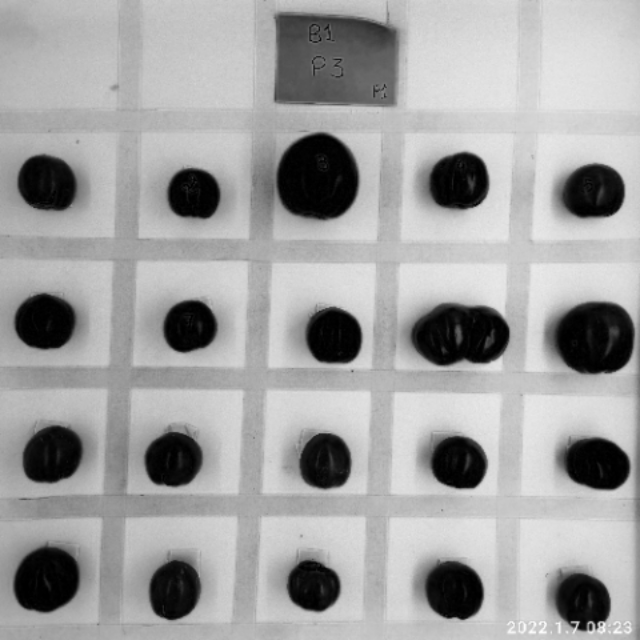

segmentation mask, threshold 0.30 + 6 erosions + 6 dilations - 8642 bytes


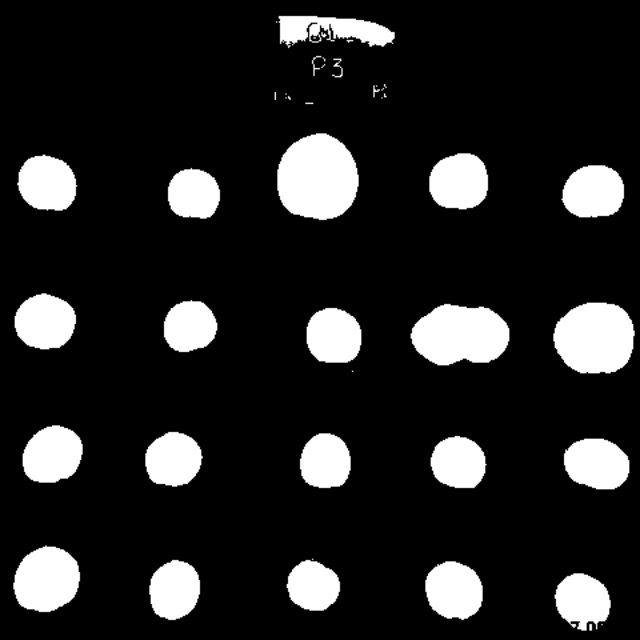

verbatim-script overlay: estimated fresh mass per fruit - 665450 bytes


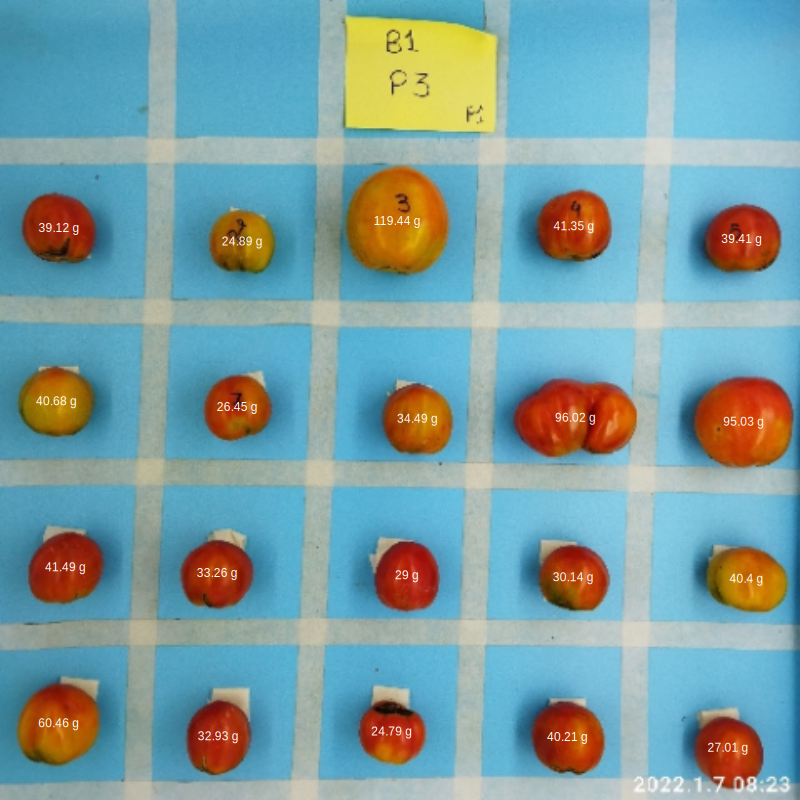

In [ ]:
# Embed the captured stage images as notebook outputs (all rendered by the author's code)
import os
from IPython.display import Image as IPyImage, display
for name, path in [("blue-channel grayscale (author gray_scale method=\"b\")","/content/step_gray.png"),
                   ("segmentation mask, threshold 0.30 + 6 erosions + 6 dilations","/content/step_seg.png"),
                   ("verbatim-script overlay: estimated fresh mass per fruit","/content/verbatim_output.png")]:
    assert os.path.exists(path), path
    print(name, "-", os.path.getsize(path), "bytes")
    display(IPyImage(filename=path, width=420))

## Interpretation, differences, validation record / 解釈と検証記録

- **What was executed:** the author's `RotinaGitHub.R` **unmodified** on the repository's
  own sample image, on a fresh Colab **CPU** runtime. All segmentation parameters
  (480×480, blue channel, threshold 0.30, fillHull, 6 erosions + 6 dilations) and the
  mass model (`grams = PixelArea*0.0473 − 24.874`) are exactly the authors'.
- **What this does and does not show:** a one-image run demonstrates the method's
  mechanics and produces a Fig. 2-style overlay; it does **not** reproduce the paper's
  dataset-level validation (R² = 0.9404 train / 0.9168 on held-out blocks, diallel GCA/SCA
  rankings via GENES) — those require the request-only raw data.
- **Adaptations (documented, algorithm-preserving):** Python cell is only a launcher for
  `Rscript`; plots are captured into PNG devices because headless R has no screen device.
  No scientific parameter was changed.
- **Provenance:** script + image = commit `153fa332f01004521b1a18f9f1bd8d4a70bc4a35`
  (blob SHA-1 verified); ExpImage 0.9.0 from the CRAN Archive (package archived 2025-02-02);
  EBImage from Bioconductor. The SandraPaper repository displays no license file — reuse
  beyond viewing/running is not established by this notebook.
- **日本語:** 著者スクリプトを無改変でCPUランタイム実行しました。Pythonは起動器のみ、
  作図はPNGデバイス経由という（アルゴリズムに影響しない）適応のみです。1枚の実行は手法の
  機構を示すものであり、論文のデータセット精度検証（R²=0.9404/0.9168、ダイヤル解析）の
  再現ではありません（生データは請求制）。

**References:** Paper: SciELO HTML (CC-BY 4.0), DOI 10.1590/s0102-0536-2025-e286631 ·
Code: github.com/AlcineiAzevedo/SandraPaper @153fa332 · ExpImage 0.9.0, CRAN Archive ·
EBImage, Bioconductor.